Data Preparation and Sampling
This stage examines the cleaned population, checks potential outliers using the IQR rule, visualises the data, and draws a reproducible stratified sample of 64 Forwards and 64 Midfielders.

NB: potential outliers are flagged, not automatically deleted. Extreme SoT/90 values can be legitimate football performances, so removing them without a substantive reason could bias the analysis.


In [1]:
import pandas as pd
import numpy as np #im
import matplotlib.pyplot as plt
import os

input_file = "Wrangled_player_data.csv"
if not os.path.exists(input_file):
    raise FileNotFoundError("Run Notebook 1 first to create the cleaned population CSV.")

df_clean = pd.read_csv(input_file)

print("Cleaned population shape:", df_clean.shape)
print(df_clean["Position_Group"].value_counts())
display(df_clean.head())


Cleaned population shape: (608, 11)
Position_Group
Midfielder    385
Forward       223
Name: count, dtype: int64


,Player,Pos,Squad,Age,90s,Sh,SoT,SoT/90,Primary_Position,Position_Group,Player_ID
0,Brenden Aaronson,MF,us USA,25,0.8,3,1,1.18,MF,Midfielder,PL0001
1,Thelo Aasgaard,MF,no Norway,24,1.0,2,1,1.00,MF,Midfielder,PL0002
2,Hamza Abdelkarim,FW,eg Egypt,18,0.7,0,0,0.00,FW,Forward,PL0003
3,Yusuf Abdurisag,FW,qa Qatar,26,1.1,0,0,0.00,FW,Forward,PL0004
4,Elias Achouri,"FW,MF",tn Tunisia,27,0.5,3,1,2.09,FW,Forward,PL0005


In [2]:
# Check potential SoT/90 outliers separately within each position group using the IQR rule.
def flag_iqr_outliers(group):
    q1 = group["SoT/90"].quantile(0.25)
    q3 = group["SoT/90"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    result = group.copy()
    result["IQR_Lower_Bound"] = lower
    result["IQR_Upper_Bound"] = upper
    result["Potential_Outlier"] = (
        (result["SoT/90"] < lower) | (result["SoT/90"] > upper)
    )
    return result

df_prepared = (
    df_clean.groupby("Position_Group", group_keys=False)
            .apply(flag_iqr_outliers)
            .reset_index(drop=True)
)

outlier_summary = (
    df_prepared.groupby("Position_Group")["Potential_Outlier"]
               .agg(["sum", "count"])
               .rename(columns={"sum":"Potential_Outliers", "count":"Total_Players"})
)
outlier_summary["Percent_Outliers"] = (
    100 * outlier_summary["Potential_Outliers"] / outlier_summary["Total_Players"]
)

print("Potential SoT/90 outliers using the 1.5 × IQR rule:")
display(outlier_summary)

print("\nPotential outlier records:")
display(
    df_prepared.loc[df_prepared["Potential_Outlier"],
                    ["Player_ID","Player","Position_Group","90s","SoT/90",
                     "IQR_Lower_Bound","IQR_Upper_Bound"]]
    .sort_values(["Position_Group","SoT/90"], ascending=[True,False])
)


Potential SoT/90 outliers using the 1.5 × IQR rule:


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9088\720564154.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(flag_iqr_outliers)


,Potential_Outliers,Total_Players,Percent_Outliers
Position_Group,,,
Forward,10,223,4.484305
Midfielder,25,385,6.493506



Potential outlier records:


,Player_ID,Player,Position_Group,90s,SoT/90,IQR_Lower_Bound,IQR_Upper_Bound
151,PL0152,Ismael Díaz,Forward,0.4,4.86,-1.8825,3.1375
18,PL0019,Almoez Ali,Forward,0.2,4.74,-1.8825,3.1375
387,PL0388,Neymar,Forward,0.4,4.62,-1.8825,3.1375
247,PL0248,Yang Hyun-jun,Forward,0.2,4.50,-1.8825,3.1375
75,PL0076,Nadhir Benbouali,Forward,0.5,4.00,-1.8825,3.1375
341,PL0342,Jean-Philippe Mateta,Forward,0.3,3.75,-1.8825,3.1375
381,PL0382,Duckens Nazon,Forward,0.3,3.75,-1.8825,3.1375
591,PL0592,Tete Yengi,Forward,0.3,3.75,-1.8825,3.1375
105,PL0106,Jaminton Campaz,Forward,0.8,3.60,-1.8825,3.1375
135,PL0136,Promise David,Forward,0.9,3.38,-1.8825,3.1375


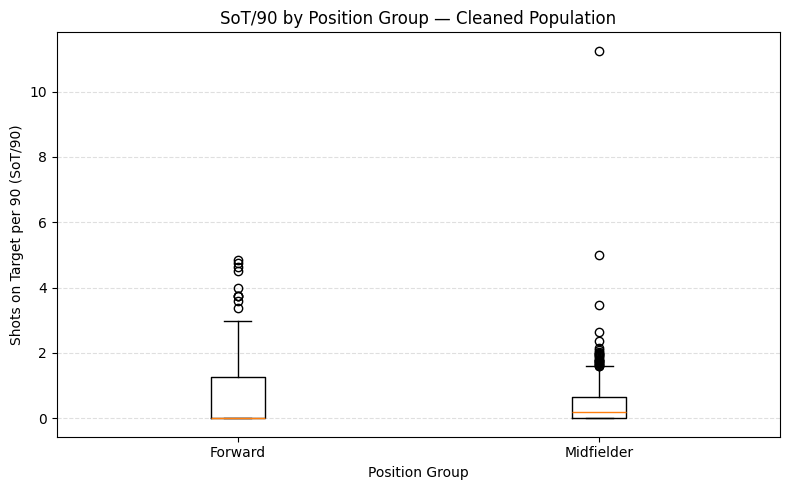

In [3]:
# Boxplot: useful for seeing median, spread and potential extreme values.
plt.figure(figsize=(8, 5))
data_to_plot = [
    df_prepared.loc[df_prepared["Position_Group"] == "Forward", "SoT/90"],
    df_prepared.loc[df_prepared["Position_Group"] == "Midfielder", "SoT/90"]
]
plt.boxplot(data_to_plot, tick_labels=["Forward", "Midfielder"])
plt.title("SoT/90 by Position Group — Cleaned Population")
plt.xlabel("Position Group")
plt.ylabel("Shots on Target per 90 (SoT/90)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


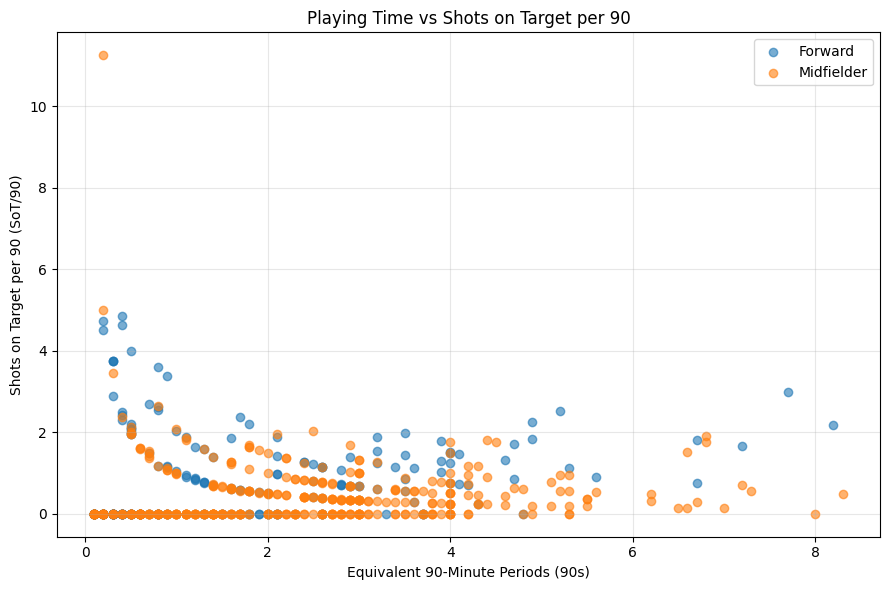

In [4]:
# Scatterplot: examine whether SoT/90 behaves differently for players with different playing time.
plt.figure(figsize=(9, 6))

for position in ["Forward", "Midfielder"]:
    subset = df_prepared[df_prepared["Position_Group"] == position]
    plt.scatter(subset["90s"], subset["SoT/90"], alpha=0.6, label=position)

plt.title("Playing Time vs Shots on Target per 90")
plt.xlabel("Equivalent 90-Minute Periods (90s)")
plt.ylabel("Shots on Target per 90 (SoT/90)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


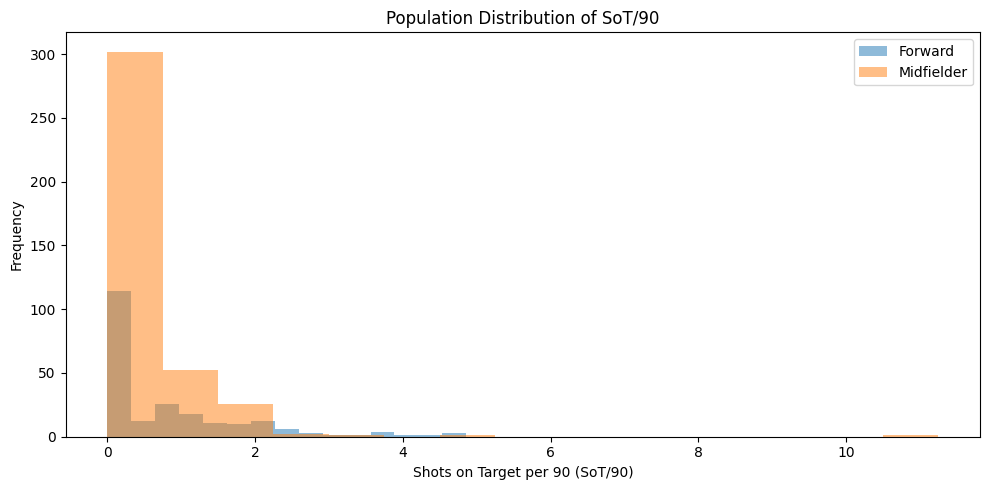

In [5]:
# Population histograms before sampling.
plt.figure(figsize=(10, 5))

for position in ["Forward", "Midfielder"]:
    subset = df_prepared[df_prepared["Position_Group"] == position]["SoT/90"]
    plt.hist(subset, bins=15, alpha=0.5, label=position)

plt.title("Population Distribution of SoT/90")
plt.xlabel("Shots on Target per 90 (SoT/90)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
# Reproducible stratified random sampling.
# We sample the same number from each position because the research question directly compares the two groups.
SAMPLE_SIZE_PER_GROUP = 64
RANDOM_STATE = 42

forwards = df_prepared[df_prepared["Position_Group"] == "Forward"]
midfielders = df_prepared[df_prepared["Position_Group"] == "Midfielder"]

if len(forwards) < SAMPLE_SIZE_PER_GROUP or len(midfielders) < SAMPLE_SIZE_PER_GROUP:
    raise ValueError("One position group contains fewer than 64 eligible players.")

forward_sample = forwards.sample(n=SAMPLE_SIZE_PER_GROUP, random_state=RANDOM_STATE)
midfielder_sample = midfielders.sample(n=SAMPLE_SIZE_PER_GROUP, random_state=RANDOM_STATE)

sample_df = pd.concat([forward_sample, midfielder_sample], ignore_index=True)

print("Sample size by position:")
print(sample_df["Position_Group"].value_counts())
print("\nTotal sample size:", len(sample_df))

# Check how many potential IQR outliers happened to enter the random sample.
print("\nPotential outliers in the selected sample:")
print(sample_df.groupby("Position_Group")["Potential_Outlier"].sum())


Sample size by position:
Position_Group
Forward       64
Midfielder    64
Name: count, dtype: int64

Total sample size: 128

Potential outliers in the selected sample:
Position_Group
Forward       2
Midfielder    6
Name: Potential_Outlier, dtype: int64


In [7]:
# Export sampled layer file to be used by subsequent notebooks.

sample_df.to_csv("sampled_Player_data.csv",
                 index=False, encoding="utf-8-sig")

print("Exported layer :")

print("sampled_Player_data.csv")



Exported layer :
sampled_Player_data.csv
